# MP2 Parts 2 & 3 — time series, gaps, themes (melawady)
Needs `melawady_project_summary.csv`, `melawady_gh_stats.csv` and `melawady_gh_recent_commits.csv` produced by `melawady.ipynb`.

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NETID = 'melawady'
df = pd.read_csv(f'{NETID}_project_summary.csv', sep=';')
df.columns = ['project', 'commit', 'author', 'time', 'message']
df['message'] = df['message'].fillna('').astype(str)
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
gh_stats = pd.read_csv(f'{NETID}_gh_stats.csv', sep=';').set_index('project')
gh_recent = pd.read_csv(f'{NETID}_gh_recent_commits.csv', sep=';') if os.path.exists(f'{NETID}_gh_recent_commits.csv') else pd.DataFrame()
PROJECTS = sorted(df['project'].unique())
print(len(PROJECTS), 'projects,', len(df), 'commits')

10 projects, 96702 commits


## Part 2 — monthly time series, CSV per project, and plots (300 DPI)

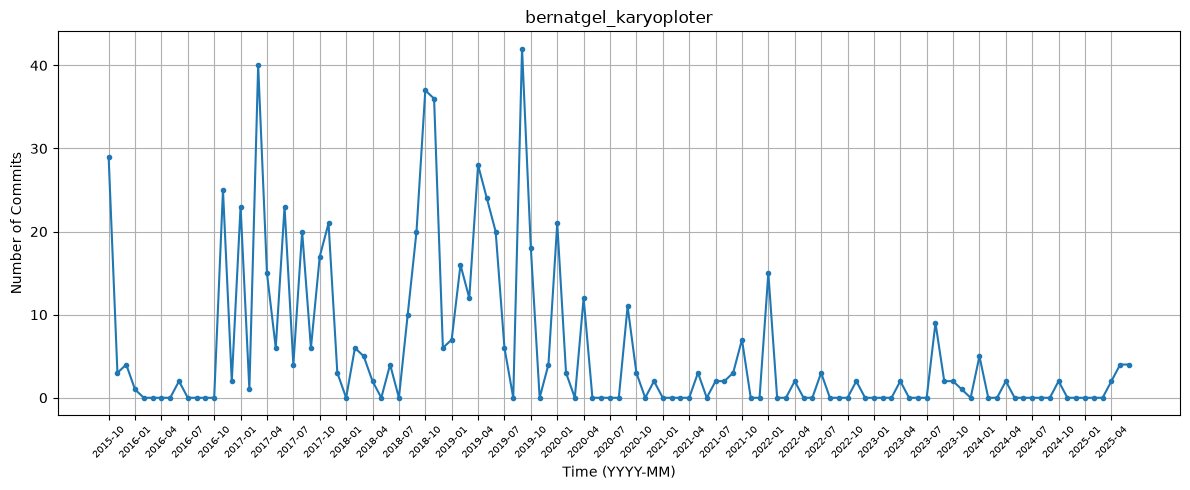

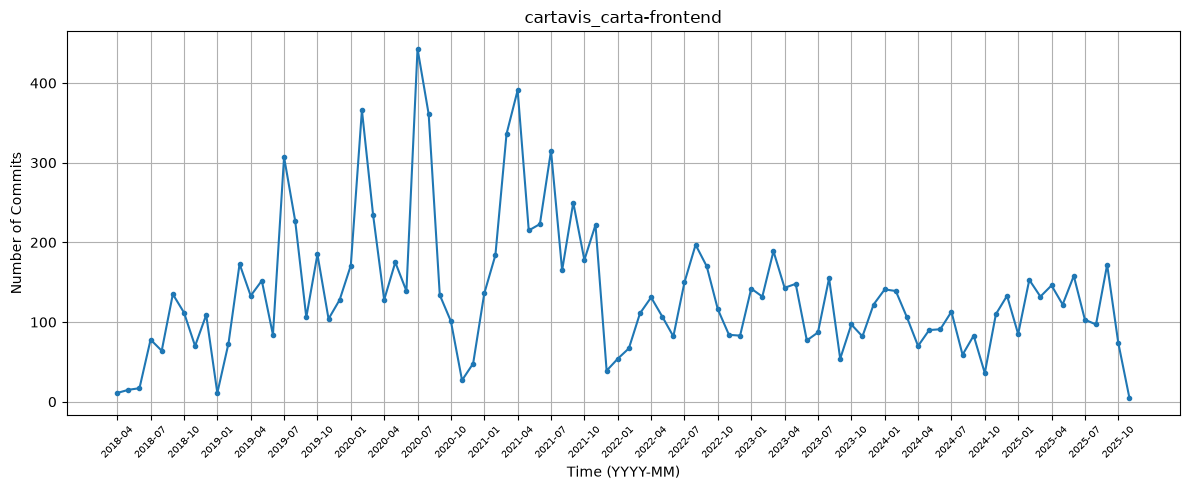

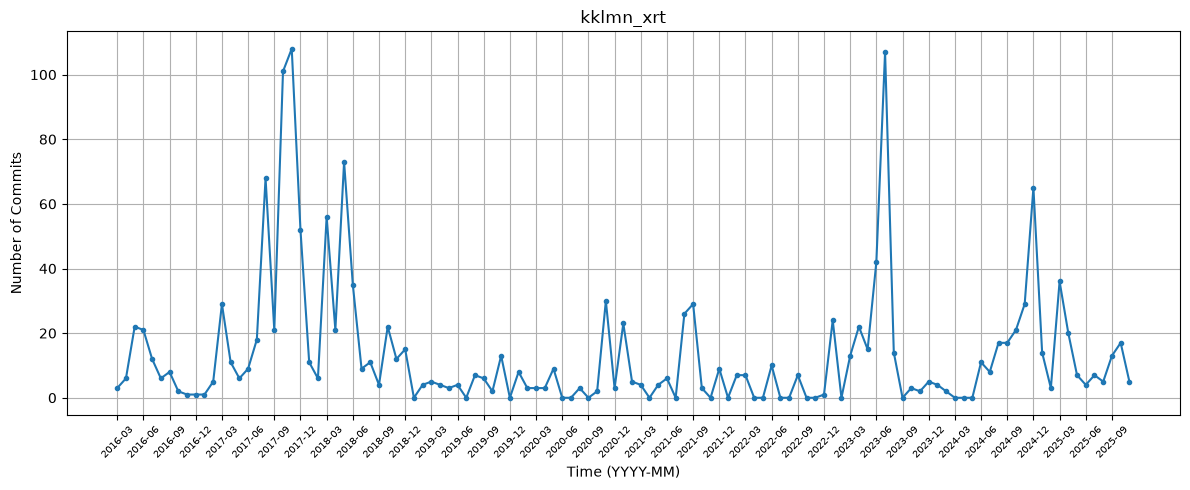

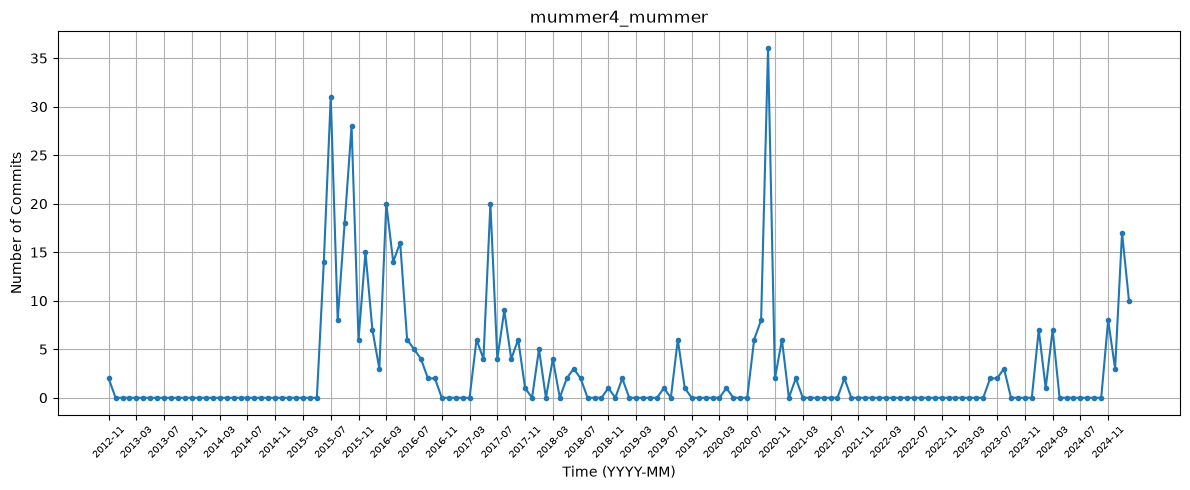

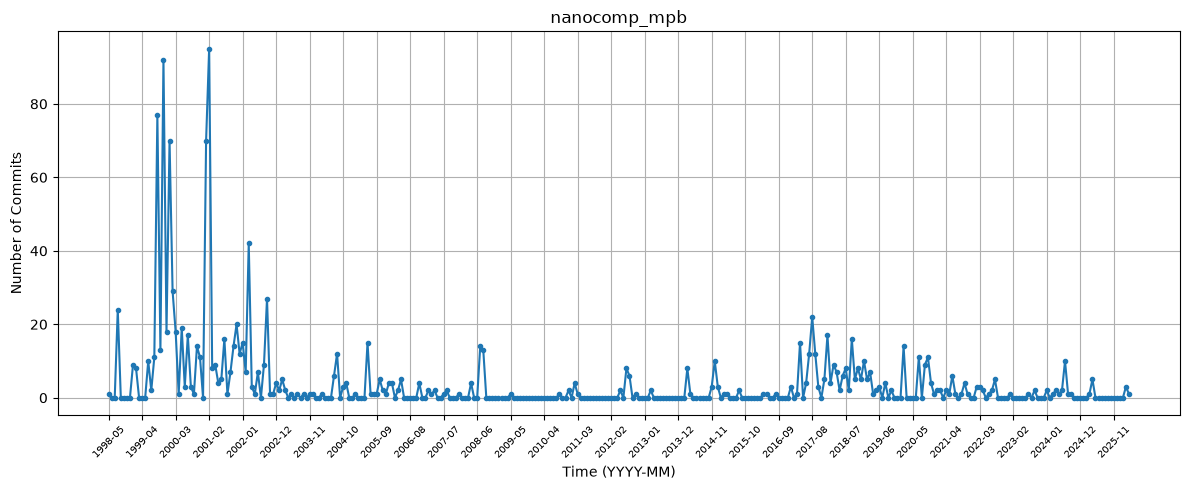

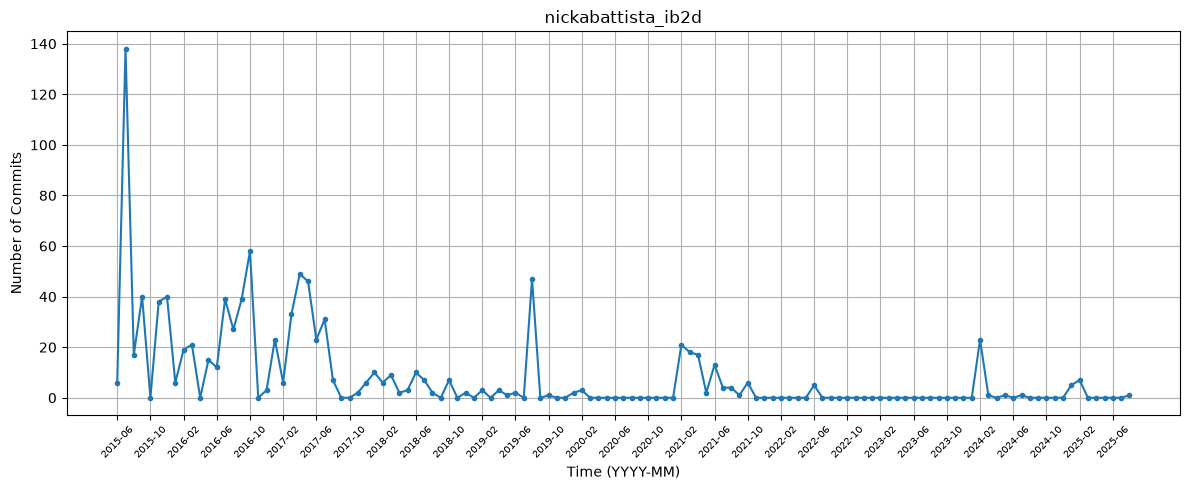

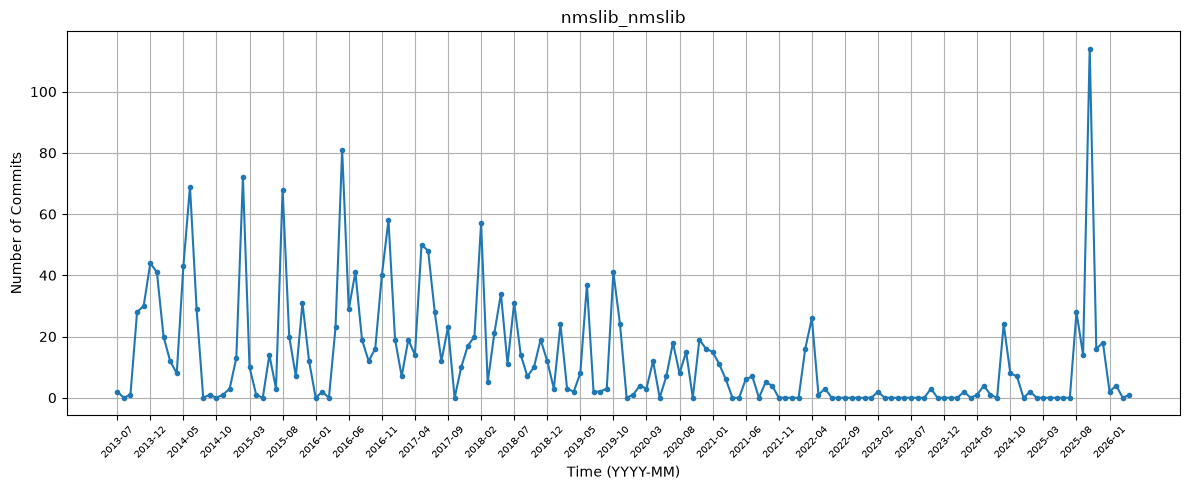

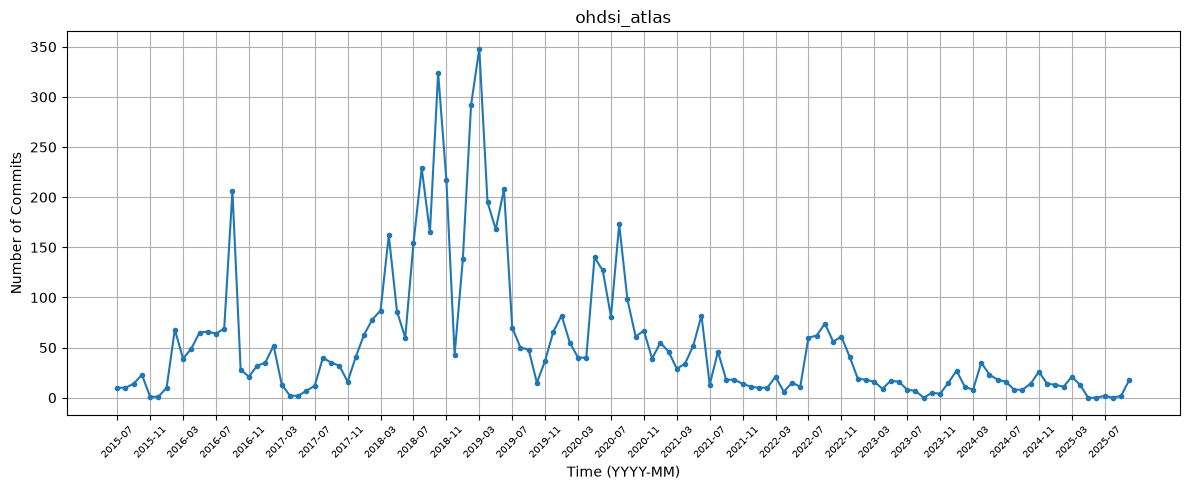

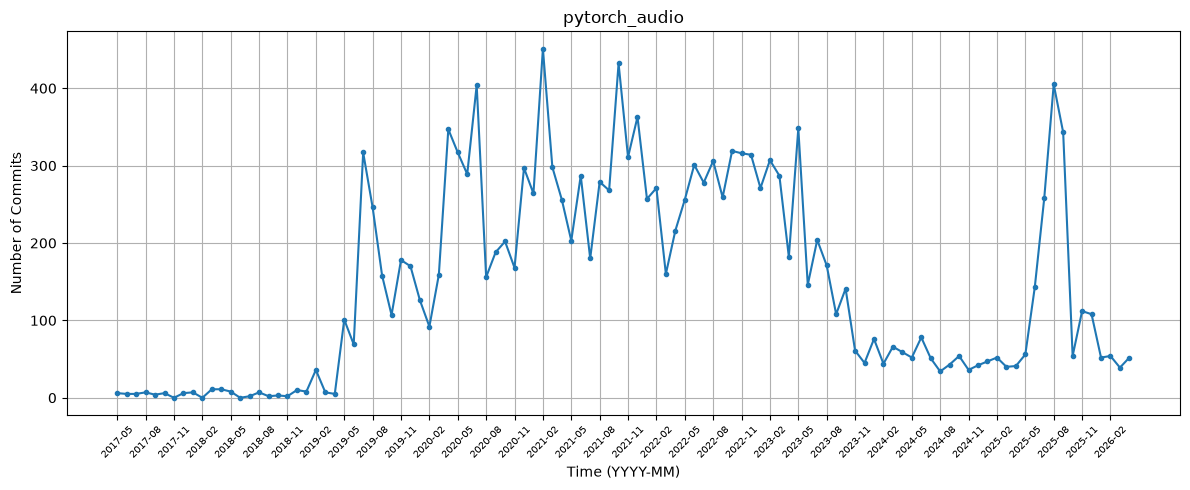

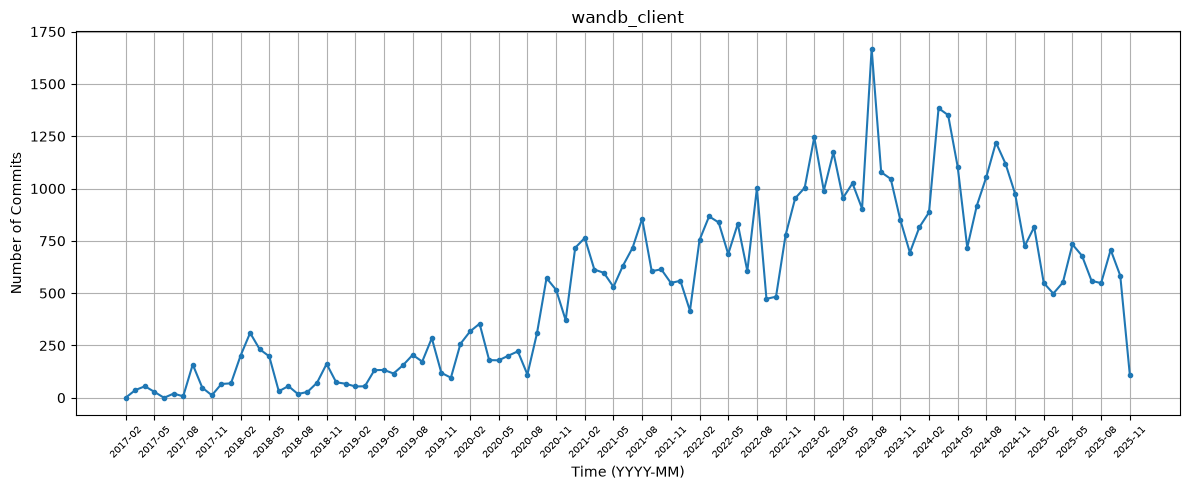

In [2]:
def monthly_series(prj):
    counts = df[df['project'] == prj].groupby('Month').size()
    months = pd.period_range(counts.index.min(), counts.index.max(), freq='M').strftime('%Y-%m')
    return pd.DataFrame({'Month': months, '#Commits': counts.reindex(months, fill_value=0).values})

SERIES = {}
for prj in PROJECTS:
    ts = monthly_series(prj)
    SERIES[prj] = ts
    ts.to_csv(f'{NETID}_commits_timeseries_{prj}.csv', sep=';', index=False)

    plt.figure(figsize=(12, 5))
    plt.plot(ts['Month'], ts['#Commits'], marker='o', markersize=3, linestyle='-')
    plt.xlabel('Time (YYYY-MM)')
    plt.ylabel('Number of Commits')
    plt.title(prj)
    plt.grid(True)
    step = max(1, len(ts) // 30)              # keep the x labels readable on long histories
    plt.xticks(range(0, len(ts), step), ts['Month'][::step], rotation=45, fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{NETID}_timeseries_{prj}.png', dpi=300)
    plt.show()
    plt.close()

## Longest inactivity gap, number of gaps (≥3 zero months), activity pattern

In [3]:
def zero_runs(ts):
    """(start_idx, end_idx) of each run of consecutive zero-commit months."""
    runs, start = [], None
    for i, z in enumerate(ts['#Commits'].eq(0).tolist() + [False]):
        if z and start is None:
            start = i
        elif not z and start is not None:
            runs.append((start, i - 1)); start = None
    return runs

def gap_stats(ts):
    runs = zero_runs(ts)
    n_gaps = sum(1 for s, e in runs if e - s + 1 >= 3)
    if not runs:
        return dict(LongestGapStart='N/A', LongestGapEnd='N/A', LongestGapLength=0,
                    NumCommitsAfterLastGap=int(ts['#Commits'].sum()), NumberOfGapsInTimeline=0)
    s, e = max(runs, key=lambda r: r[1] - r[0])          # first longest run on ties
    return dict(LongestGapStart=ts['Month'][s], LongestGapEnd=ts['Month'][e],
                LongestGapLength=e - s + 1,
                NumCommitsAfterLastGap=int(ts['#Commits'][e + 1:].sum()),
                NumberOfGapsInTimeline=n_gaps)

def draft_pattern(ts):
    """Rough first guess only - look at the plot and override in PATTERN_OVERRIDE below."""
    y = ts['#Commits'].to_numpy(float)
    if len(y) < 6:
        return 'irregular'
    a, b, c = (x.mean() for x in np.array_split(y, 3))
    if len(y) >= 36:
        yc = y - y.mean()
        ac12 = (yc[:-12] * yc[12:]).sum() / max((yc ** 2).sum(), 1e-9)
        if ac12 > 0.35:
            return 'cyclical'
    if y.std() / max(y.mean(), 1e-9) < 0.6:
        return 'steady'
    if b < 0.6 * min(a, c):
        return 'U-shaped'
    if c > 1.5 * a and c >= b:
        return 'rising'
    if a > 1.5 * c and a >= b * 0.8:
        return 'declining'
    return 'irregular'

GAPS = {prj: gap_stats(SERIES[prj]) for prj in PROJECTS}
gap_table = pd.DataFrame(GAPS).T
gap_table['DraftPattern'] = [draft_pattern(SERIES[p]) for p in gap_table.index]
gap_table

,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,DraftPattern
bernatgel_karyoploter,2024-05,2024-09,5,12,9,declining
cartavis_carta-frontend,N/A,N/A,0,12474,0,irregular
kklmn_xrt,2024-03,2024-05,3,299,1,U-shaped
mummer4_mummer,2012-12,2015-05,30,403,10,declining
nanocomp_mpb,2009-06,2010-08,15,379,23,U-shaped
nickabattista_ib2d,2022-07,2024-01,19,39,5,declining
nmslib_nmslib,2022-07,2023-01,7,251,5,declining
ohdsi_atlas,2025-05,2025-06,2,22,0,declining
pytorch_audio,2017-11,2017-11,1,15823,0,irregular
wandb_client,2017-06,2017-06,1,54621,0,cyclical


Look at each plot and set the pattern you actually perceive (steady, rising, declining, U-shaped, cyclical, irregular). Anything left out keeps the draft.

In [4]:
PATTERN_OVERRIDE = {   # my reading of each plot (see Interpretation below)
    'bernatgel_karyoploter':   'declining',
    'cartavis_carta-frontend': 'steady',
    'kklmn_xrt':               'U-shaped',
    'mummer4_mummer':          'irregular',
    'nanocomp_mpb':            'declining',
    'nickabattista_ib2d':      'declining',
    'nmslib_nmslib':           'declining',
    'ohdsi_atlas':             'declining',
    'pytorch_audio':           'irregular',
    'wandb_client':            'rising',
}
for prj in PROJECTS:
    GAPS[prj]['ActivityPattern'] = PATTERN_OVERRIDE.get(prj, gap_table.loc[prj, 'DraftPattern'])
pd.DataFrame(GAPS).T[['ActivityPattern', 'NumberOfGapsInTimeline', 'LongestGapLength']]

,ActivityPattern,NumberOfGapsInTimeline,LongestGapLength
bernatgel_karyoploter,declining,9,5
cartavis_carta-frontend,steady,0,0
kklmn_xrt,U-shaped,1,3
mummer4_mummer,irregular,10,30
nanocomp_mpb,declining,23,15
nickabattista_ib2d,declining,5,19
nmslib_nmslib,declining,5,7
ohdsi_atlas,declining,0,2
pytorch_audio,irregular,0,1
wandb_client,rising,0,1


## Interpretation

Trend read from each monthly plot (yearly totals in brackets), plus the number of gaps of at least three consecutive zero-commit months.

| Project | Pattern | # gaps ≥3 months | Explanation |
|---|---|---|---|
| nickabattista_ib2d | declining | 5 | Busy 2015–2017 (279, 239, 226 commits/yr) while the IB2d papers were being written, then a long tail of small bursts (5 in 2020, 0 in 2023). Single academic maintainer: activity comes in short bursts tied to new versions (Feb 2024, Feb 2025). |
| cartavis_carta-frontend | steady | 0 | Ramp-up 2018–2021 (611 → 2654/yr), then a stable 1,200–1,400 commits/yr with no empty month at all. A funded, multi-institution team with a regular release process and dependabot updates. |
| nanocomp_mpb | declining | 23 | Very intense 1999–2002 (240, 186, 261/yr) when MPB was written, then a trickle of a few commits a year with many multi-month gaps. A small revival in 2017–2018 (77, 89) when the Python interface and docs were added. |
| kklmn_xrt | U-shaped | 1 | High in 2017–2018 (429, 275), a quiet middle 2019–2022 (32–109/yr), and high again 2023–2025 (247, 174, 131) with large bursts in mid-2023 and early 2025. |
| pytorch_audio | irregular | 0 | Tiny until 2019, a big rise and plateau 2020–2022 (~3,000/yr), a drop in 2024 (635), a sharp spike in mid-2025 (I/O moved to TorchCodec, deprecations removed), then low again. No single long-term direction. |
| bernatgel_karyoploter | declining | 9 | Peak 2017–2019 (up to 179/yr, monthly spikes of ~40), then 9–22/yr with commits clustered around Bioconductor's April/October release branches. |
| wandb_client | rising | 0 | Continuous growth from 433 commits in 2017 to ~12,500/yr in 2023–2024 as the company and team grew. A slight dip in 2025 but still far above earlier years, never an empty month after June 2017. |
| ohdsi_atlas | declining | 0 | Rises to a peak in 2018–2019 (~1,650/yr, monthly peaks above 300), then declines steadily to 80–200/yr in 2023–2025. Only one 2-month gap (May–June 2025). |
| mummer4_mummer | irregular | 10 | A 30-month silence after the 2012 import, a burst in 2015–2016 (MUMmer4 rewrite), then isolated spikes (2017, Oct 2020, 2024) separated by long empty stretches. |
| nmslib_nmslib | declining | 5 | 200–320 commits/yr in 2014–2018, falling to 5 in 2023, with a one-off burst in late 2025 (192 commits, mostly wheel/CI build fixes). |

## Part 3.1 — commits before and after the longest gap, and their themes
Themes come from a keyword classifier as a starting point; check them against the messages printed below.

In [5]:
BOT_AUTHORS = re.compile(r'\[bot\]|dependabot|renovate|github-actions|pre-commit-ci|greenkeeper|travis|jenkins|codecov|pytorchbot|facebook-github-bot', re.I)
RULES = [  # (theme, pattern) checked in this order; version bumps count as Release, not Dependency updates
    ('Security patches',       r'security|\bcve\b|vulnerab|\bxss\b|injection|sanitiz'),
    ('Release',                r'\brelease|version bump|bump(ed)?( x\.y\.z| up)?( the)? version|\bv\d+\.\d+|changelog|\btag(ged)?\b|pypi|\bcran\b|compatibility wheel|version macro'),
    ('Dependency updates',     r'\bbump\b|dependenc|requirements|\bupgrade\b|package(-lock)?\.json|\bpin(ned)?\b|\bdeps?\b|yarn\.lock|environment\.yml|update .* to v?\d'),
    ('Documentation updates',  r'\bdocs?\b|documentation|readme|docstring|typo|tutorial|comment|\bwiki\b|manual|vignette|\.md\b|citation'),
    ('Bug fixes',              r'\bfix|\bbug|\berror|crash|\bissue|\bpatch|correct|resolv|wrong|broken|segfault|hotfix|revert|workaround|\bcheck|handle|\bwarn|escape'),
    ('Feature development',    r'\badd|implement|feature|support|\bnew\b|introduc|enable|allow|\bimprove|extend|refactor|optimi'
                               r'|speed|faster|sped up|efficien|performance|rename|\bmove|creat|example|tuning|elaborate|suppress'
                               r'|convert|replace|transform|compand|initial version|capabilit|functionality|\bwrite|object'),
]

def theme(author, message):
    if BOT_AUTHORS.search(str(author)) or re.search(r'auto-?generated|\[bot\]|\[skip ci\]', message, re.I):
        return 'Automated bot contributions'
    if re.match(r'Merge [0-9a-f]{40} into [0-9a-f]{40}', message):
        return 'Other'   # GitHub's automatic pull-request test merge, no content of its own
    text = message
    m = re.match(r'Merge (pull request #\d+ from \S+|branch \S+.*)', message)
    if m:   # use the PR title / branch name that follows "Merge pull request"
        text = message[len(m.group(0)):] + ' ' + m.group(0).split('/')[-1].replace('-', ' ').replace('_', ' ')
    for t, pat in RULES:
        if re.search(pat, text, re.I):
            return t
    return 'Other'

def top2(frame):
    if frame.empty:
        return 'N/A'
    return ':'.join(frame.apply(lambda r: theme(r['author'], r['message']), axis=1).value_counts().index[:2])

gap_rows, THEMES = [], {}
for prj in PROJECTS:
    g = GAPS[prj]
    d = df[df['project'] == prj].sort_values('time')
    if g['LongestGapLength'] == 0:
        THEMES[prj] = ('N/A', 'N/A', d.iloc[0:0], d.iloc[0:0])
        continue
    gap_start = pd.Period(g['LongestGapStart'], 'M').start_time.timestamp()
    after_gap = (pd.Period(g['LongestGapEnd'], 'M') + 1).start_time.timestamp()
    pre = d[d['time'] < gap_start].tail(10)
    post = d[d['time'] >= after_gap].head(10)
    THEMES[prj] = (top2(pre), top2(post), pre, post)
    for label, part in (('pre', pre), ('post', post)):
        out = part[['project', 'commit', 'author', 'time', 'message']].copy()
        out.insert(0, 'pre/post', label)
        gap_rows.append(out)

gap_commits = pd.concat(gap_rows, ignore_index=True)
gap_commits.columns = ['pre/post', 'project_wocid', 'commit_sha1', 'author', 'time', 'commit message']
gap_commits.to_csv(f'{NETID}_project_gap_commits.csv', sep=';', index=False)
pd.DataFrame({p: {'BeforeThemes': THEMES[p][0], 'AfterThemes': THEMES[p][1]} for p in PROJECTS}).T

,BeforeThemes,AfterThemes
bernatgel_karyoploter,Release:Bug fixes,Release:Bug fixes
cartavis_carta-frontend,N/A,N/A
kklmn_xrt,Bug fixes:Documentation updates,Feature development:Bug fixes
mummer4_mummer,Feature development:Bug fixes,Feature development:Bug fixes
nanocomp_mpb,Feature development:Bug fixes,Bug fixes:Feature development
nickabattista_ib2d,Documentation updates:Bug fixes,Documentation updates:Feature development
nmslib_nmslib,Other:Bug fixes,Feature development:Bug fixes
ohdsi_atlas,Bug fixes:Other,Other:Bug fixes
pytorch_audio,Bug fixes:Feature development,Documentation updates:Bug fixes
wandb_client,Other:Bug fixes,Release:Bug fixes


## Part 3.2 — evidence for interpreting each gap
For each project this prints the commits around the gap, who came back, and GitHub search links for issues / PRs opened just before and after the gap. Read these, then fill in `ANSWERS` below.

In [6]:
import unicodedata

def ident(a):
    a = unicodedata.normalize('NFKD', str(a)).encode('ascii', 'ignore').decode()   # Marçais -> Marcais
    m = re.match(r'\s*(.*?)\s*<(.*)>', a)
    return (m.group(1).lower(), m.group(2).lower()) if m else (str(a).lower(), '')

def who_recovered(prj):
    g = GAPS[prj]
    if g['LongestGapLength'] == 0:
        return 'N/A active Project'
    if g['NumCommitsAfterLastGap'] == 0:
        return 'N/A not recovered'
    d = df[df['project'] == prj]
    gap_start = pd.Period(g['LongestGapStart'], 'M').start_time.timestamp()
    after_gap = (pd.Period(g['LongestGapEnd'], 'M') + 1).start_time.timestamp()
    before = [ident(a) for a in d[d['time'] < gap_start]['author'].unique()]
    names, mails = {n for n, _ in before}, {e for _, e in before if e}
    until = (pd.Period(g['LongestGapEnd'], 'M') + 13).start_time.timestamp()
    after = d[(d['time'] >= after_gap) & (d['time'] < until)]   # first 12 months after the gap
    returning = after['author'].map(lambda a: ident(a)[0] in names or ident(a)[1] in mails)
    n_ret, n_new = after[returning]['author'].nunique(), after[~returning]['author'].nunique()
    share = returning.mean()
    kind = 'Same people' if share >= 0.8 else 'New people' if share <= 0.2 else 'Mix of returning and new'
    return f'{kind}: {n_ret} returning / {n_new} new authors, {share:.0%} of commits in the 12 months after the gap by returning authors'

def gh_links(prj):
    g = GAPS[prj]
    full = gh_stats.loc[prj].get('gh_full_name', prj) if prj in gh_stats.index else prj
    s = (pd.Period(g['LongestGapStart'], 'M') - 3).start_time.date()
    e = (pd.Period(g['LongestGapEnd'], 'M') + 3).end_time.date()
    return (f'https://github.com/{full}/issues?q=is%3Aissue+created%3A{s}..{e}',
            f'https://github.com/{full}/pulls?q=is%3Apr+created%3A{s}..{e}',
            f'https://github.com/{full}/commits/HEAD/README.md')

for prj in PROJECTS:
    g = GAPS[prj]
    print('=' * 100, f'\n{prj}: longest gap {g["LongestGapStart"]} .. {g["LongestGapEnd"]} '
          f'({g["LongestGapLength"]} months), {g["NumCommitsAfterLastGap"]} commits after')
    if g['LongestGapLength'] == 0:
        print('  no zero-commit month - always active'); continue
    _, _, pre, post = THEMES[prj]
    for label, part in (('BEFORE', pre), ('AFTER', post)):
        print(f'  --- {label} ---')
        for r in part.itertuples():
            first = r.message.strip().splitlines()[0][:90] if r.message.strip() else ''
            print(f'  {pd.to_datetime(r.time, unit="s").date()}  {theme(r.author, r.message)[:12]:12s}  '
                  f'{str(r.author)[:28]:28s}  {first}')
    print('  who recovered:', who_recovered(prj))
    for link in gh_links(prj):
        print('  ', link)

bernatgel_karyoploter: longest gap 2024-05 .. 2024-09 (5 months), 12 commits after
  --- BEFORE ---
  2023-10-24  Release       J Wokaty <jennifer.wokaty@sp  bump x.y.z version to even y prior to creation of RELEASE_3_18 branch
  2023-10-24  Release       J Wokaty <jennifer.wokaty@sp  bump x.y.z version to odd y following creation of RELEASE_3_18 branch
  2023-11-10  Bug fixes     Bernat <bernatgel@gmail.com>  Fixed letter color selection
  2024-01-11  Bug fixes     Bernat <bernatgel@gmail.com>  Better error for multiple colors in kpArea
  2024-01-11  Documentatio  Bernat <bernatgel@gmail.com>  Updated docs to clarify the color specification
  2024-01-11  Other         Bernat <bernatgel@gmail.com>  Merge branch 'detachedhead' into devel
  2024-01-11  Other         Bernat <bernatgel@gmail.com>  Updated DESCRIPTION to use Authors@R
  2024-01-11  Release       Bernat <bernatgel@gmail.com>  Version Bump
  2024-04-30  Release       J Wokaty <jwokaty@users.nore  bump x.y.z version to even y 

## Current status and recent themes
Inactive = no GitHub commit in the 6 months before 2025-09-30 (last commit before 2025-04-01). Recent themes use the 10 latest GitHub commits when available, otherwise the 10 latest WoC commits.

In [7]:
CUTOFF = pd.Timestamp('2025-04-01')   # README: inactive if no commit in the 6 months before 2025-09-30
STATUS = {}
for prj in PROJECTS:
    last = gh_stats.loc[prj].get('lastGHCommitDate') if prj in gh_stats.index else None
    if pd.isna(last):
        last = pd.to_datetime(df[df['project'] == prj]['time'].max(), unit='s')
    status = 'Active' if pd.Timestamp(last) >= CUTOFF else 'Inactive'
    rec = gh_recent[gh_recent['project'] == prj] if len(gh_recent) else pd.DataFrame()
    if len(rec):
        rec = rec.rename(columns={'commit message': 'message'})
        rec['message'] = rec['message'].fillna('').astype(str)
    else:
        rec = df[df['project'] == prj].sort_values('time').tail(10)
    STATUS[prj] = {'lastCommit': str(last)[:10], 'Currentstatus': status, 'RecentThemes': top2(rec)}
pd.DataFrame(STATUS).T

,lastCommit,Currentstatus,RecentThemes
bernatgel_karyoploter,2026-04-28,Active,Release:Feature development
cartavis_carta-frontend,2026-09-23,Active,Automated bot contributions:Release
kklmn_xrt,2026-09-24,Active,Other:Bug fixes
mummer4_mummer,2025-02-04,Inactive,Feature development:Other
nanocomp_mpb,2026-05-27,Active,Bug fixes:Documentation updates
nickabattista_ib2d,2026-06-14,Active,Feature development:Bug fixes
nmslib_nmslib,2026-01-12,Active,Other:Bug fixes
ohdsi_atlas,2025-11-09,Active,Bug fixes:Feature development
pytorch_audio,2026-09-23,Active,Other:Bug fixes
wandb_client,2026-09-25,Active,Feature development:Other


## Your answers (Part 3.2 + reflections)
Fill these in from the evidence above — commit messages first, then issues / PRs / README history. Point to concrete facts (dates, commit messages, issue numbers). `reflection` becomes the body of `melawady_reflection_<project>.md`; `notes` is its 2–4 sentence summary.

In [8]:
ANSWERS = {
    'bernatgel_karyoploter': dict(
        gap_reason='Low maintainer availability on a mature package. The last pre-gap commits (2024-04-30) are only Bioconductor core-team version bumps for the RELEASE_3_19 branch, and the maintainer Bernat Gel had not committed since 2024-01-11. All 12 issues opened in 2024 (#147-#158) are still open with 0-3 comments, so user reports went unanswered.',
        why_recovered='Activity resumed through the Bioconductor release cycle: J Wokaty bumped versions for RELEASE_3_20 on 2024-10-29. Real maintainer work only returned on 2025-05-27/06-06 (Fixes scipen handling, Removes strand from plot.region, version bump).',
        reflection='''karyoploteR was most active in 2017-2019 (up to 179 commits a year) and has declined to roughly 10-20 commits a year since 2021, with 9 separate gaps of three or more months.
Most commits after 2021 come in pairs on the same day from the Bioconductor core team ("bump x.y.z version to even y prior to creation of RELEASE_3_xx branch"), every April and October. Those are release-cycle bookkeeping, not development.
The longest gap (May-September 2024) was easy to interpret: it falls between two Bioconductor releases and the maintainer had already stopped committing in January 2024, while new GitHub issues (#150-#154) were left unanswered.
Recovery is only partial. The October 2024 commits are automated release bumps, and the author himself only came back for a few bug fixes in May-June 2025. The package is maintained, not actively developed.''',
        notes='Declining activity since 2019 with 9 gaps of 3+ months. Commits now mostly follow the Bioconductor twice-yearly release bumps. The 2024 gap matches a period where the sole maintainer stopped committing and all new issues stayed unanswered, and he returned only for small fixes in mid-2025.',
    ),
    'cartavis_carta-frontend': dict(
        gap_reason='',
        why_recovered='',
        reflection='''CARTA frontend never had a month without commits between April 2018 and November 2025 (12,474 WoC commits by 76 authors), so there is no gap to interpret.
Activity ramped up from 611 commits in 2018 to a peak of 2,654 in 2021 and then settled at a steady 1,200-1,400 commits a year, around 100-150 a month.
This is the profile of a funded, multi-institution team (CARTAvis is developed by observatory and university groups) working on regular releases. The latest GitHub commits are a mix of features ("feat: support string-type coordinate columns"), bug fixes and dependabot dependency bumps.
The pattern was easy to read: steady, continuous development with automated dependency maintenance on top.''',
        notes='Always active: no zero-commit month in 7.5 years and 0 gaps of 3+ months. Activity rose to a 2021 peak and has been steady at ~100-150 commits a month since, driven by a funded team plus dependabot updates.',
    ),
    'kklmn_xrt': dict(
        gap_reason='A short pause by a small core team, not abandonment. Before the gap (Dec 2023 - Feb 2024) Roman Chernikov and Konstantin Klementiev were fixing crystal code (Fix volume calculation for non-cubic crystals in pytte_x). During the gap the maintainers kept answering issues (#172 had 9 comments, #176 had 18) but made no commits, which suggests they were busy with other work rather than leaving.',
        why_recovered='Klementiev resumed on 2024-06-05 with new functionality (tuning_curves loop, add import of predefined materials on 2024-06-10, additions to diffract output), apparently driven by user questions in issues #176-#180 about energy settings and materials.',
        reflection='''xrt has a U-shaped history: very active in 2017-2018 (429 and 275 commits), quiet in 2019-2022, and active again in 2023-2025 with big bursts in mid-2023 and early 2025.
The longest gap is short (March-May 2024, 3 months) and it is the only gap of 3+ months in ten years.
The gap was easy to interpret. The same two maintainers committed before and after (96% of commits in the following year were by returning authors), and the issue tracker shows them still responding to users during the quiet months. The pause looks like normal workload variation for scientists who maintain the code alongside their main jobs.
The project is clearly active today: the most recent GitHub commits (September 2026) add plotting and rendering features.''',
        notes='U-shaped activity with only 1 gap of 3+ months (Mar-May 2024). The same two maintainers worked before and after the gap and kept answering issues during it, so it was a short workload pause rather than abandonment. The project is currently very active.',
    ),
    'mummer4_mummer': dict(
        gap_reason='The repository did not have an active project yet. Its first commits (2012-11-08, Initial version 3.23) import the old MUMmer 3.23 code base and build setup, after which nothing happened. There were no issues or PRs at all before October 2015, and the README was only created on 2015-10-22, so the code sat dormant until the MUMmer4 rewrite began.',
        why_recovered='Guillaume Marçais started the MUMmer4 rewrite in June 2015 (UnionFind an object, Use C++ I/O ... a little faster, Sort using std::sort instead of qsort. Faster.), leading to the first GitHub release v3.9.0alpha on 2015-10-28.',
        reflection='''mummer has an irregular timeline: a 30-month silence after the 2012 import, a large burst in 2015-2016, then isolated spikes (2017, October 2020, 2024-2025) with 10 gaps of 3+ months in total.
The longest gap (December 2012 - May 2015) was fairly easy to interpret once the before/after commits are read together. Before: "Initial version 3.23" (an import of the legacy code). After: a performance-focused rewrite of the same tools by the same developer. GitHub confirms it: the README and the first PR (#1) only appear in October 2015, right before the v3.9.0alpha release.
The recovery was driven by the original author: 179 of the 180 commits in the following 12 months are by Guillaume Marçais under four spellings/e-mails (Marcais, Marçais, gmarcais), and the only new person is Jan van Haarst with one README PR. Others such as Aleksey Zimin joined much later (October 2020 README updates).
By the README rule the project is now Inactive: the last GitHub commit was the 4.0.1 release on 2025-02-04 (BSD compilation fixes).''',
        notes='Irregular history with 10 gaps of 3+ months. The 30-month longest gap is simply the time between importing MUMmer 3.23 (Nov 2012) and starting the MUMmer4 rewrite (Jun 2015), both by Guillaume Marçais. The project is currently inactive by the README rule (last release 4.0.1 in Feb 2025).',
    ),
    'nanocomp_mpb': dict(
        gap_reason='Single-maintainer academic code in maintenance mode. Almost all commits before the gap are by Steven G. Johnson, whose 2008 work was on material-grid optimization through his NLopt library (renamed nlopt function, use nonlinear constrained MMA alg.). The last pre-gap commit (2009-05-01) is a small fix to mpb-split, and no other developer was active, so any period where he focused elsewhere left the code untouched. There are no GitHub issues from this period because the history was imported from an older version control system.',
        why_recovered='Johnson returned with a bug fix on 2010-09-13 (bugfix: in evectmatrix routines ... don\'t assume that scratch * 0 = 0) followed by MPI and HDF5 compile fixes, i.e. maintenance prompted by bugs rather than new development.',
        reflection='''MPB has the longest history of my projects (WoC commits back to 1998) and a declining profile: very intense in 1999-2002 when the code was written, then only a few commits a year, with 23 gaps of 3+ months.
The longest gap (June 2009 - August 2010, 15 months) was hard to interpret from GitHub alone, because there are no issues or PRs from that era. The commit messages are the main evidence: one author, a finished optimization feature in 2008, a single fix in 2009, and then bug fixes again from September 2010. That fits a mature tool whose only maintainer was working on other projects.
Recovery after the gap was slow maintenance by the same person (7 of the 8 commits in the next 12 months are by Johnson, plus one by kylkaren). A real revival came in 2017-2018 (77 and 89 commits) when new contributors (Chris Hogan, Homer Reid, Ardavan Oskooi) added the Python interface and documentation after the project moved to the NanoComp organization.
The project is still maintained today (fix #175, compiler-warning fixes in May 2026).''',
        notes='Declining activity after the original 1999-2002 development, with 23 gaps of 3+ months. The 15-month gap in 2009-2010 matches a single maintainer (Steven G. Johnson) working elsewhere, and he alone restarted it with bug fixes. A later 2017-2018 revival added the Python interface with new contributors.',
    ),
    'nickabattista_ib2d': dict(
        gap_reason='The sole maintainer, Nick Battista, wrapped up a round of work in June 2022 (typo fixes in density units, Updated README file with paper links) and then stopped. Users kept opening issues during the gap (#25 on 2022-07-28, #26, #27, #28 on 2023-07-13) and all of them are still open with 0-1 comments, so nobody was maintaining the project in that period.',
        why_recovered='Battista returned on 2024-02-03 with a performance update (Extensive speed/efficiencies tests conducted, sped up the fluid solver and force spreading) and rewrote the README over 2024-02-03/04, effectively publishing a new version. A further "Feb 2025 IB2d version" followed a year later.',
        reflection='''IB2d is a declining project with 5 gaps of 3+ months. It was very active in 2015-2017 (about 230-280 commits a year), then dropped to bursts of activity separated by quiet periods.
The longest gap (July 2022 - January 2024, 19 months) was easy to interpret. The commits before it are documentation clean-up by the maintainer, unanswered issues accumulated during it, and the same maintainer came back with a speed-up release (100% of post-gap commits by returning authors, no new contributors).
This is a typical one-person academic project: development happens when the author has time or a paper/course needs it, and versions are released roughly once a year (Feb 2024, Feb 2025).
It is still active by the README rule (bug fixes in August 2025 and June 2026), but user issues from 2022-2023 remain unanswered.''',
        notes='Declining activity with 5 gaps of 3+ months. The 19-month gap (Jul 2022 - Jan 2024) is a pause by the only maintainer, visible from unanswered issues #25-#28. He alone revived it with a performance-focused new version in Feb 2024.',
    ),
    'nmslib_nmslib': dict(
        gap_reason='The maintainer stopped after struggling with builds. The last pre-gap commits by Leonid Boytsov (searchivarius) are all CI/packaging fixes (yet another attempt fix travis build, let\'s try to build without extras, Mac ARM detection PR #516). During the gap users opened install-failure issues (#518 Python 3.10 on Windows, #519 Unable to pip install nmslib, #520 Build failure on OSX) with no commits in response. GitHub shows no commit on the default branch between 2022-03-31 and 2026-01-12.',
        why_recovered='Outside contributors restarted activity through pull requests (sad1y PR #532 on 2023-02-17, Artem Farazei and Sergey Fedorov build fixes, Tejas Shah\'s ef parameter for hnsw in 2024-05). Boytsov came back to merge them (PR #548 on 2024-06-23) and in Sep-Nov 2025 made ~150 commits to rebuild the wheels for new Python versions and Windows/macOS ARM.',
        reflection='''nmslib was very active in 2014-2018 (200-320 commits a year) and has declined since, with 5 gaps of 3+ months and only 5 commits in 2023.
The longest gap (July 2022 - January 2023, 7 months) was moderately hard to interpret. The commit messages before it show the maintainer fighting CI and packaging (Travis, Mac OS, ARM builds), and the issues during it are mostly "cannot pip install" reports. That suggests the burden of keeping binary builds working for new Python versions outgrew the time of a single maintainer.
Note that many WoC commits around the gap are GitHub "Merge <sha> into <sha>" pull-request test merges, not real changes on the main branch. In the 12 months after the gap all commits came from new people (0 returning / 3 new authors), but they were unmerged PRs.
Real recovery came from the original maintainer: merging PRs in 2024 and a large packaging push in late 2025. The project is still formally active (last commit 2026-01-12), but its default branch was untouched for almost four years.''',
        notes='Declining activity with 5 gaps of 3+ months. The 7-month gap in 2022 followed a long fight with CI/packaging, while install-failure issues (#518-#529) piled up. New contributors\' PRs restarted activity, and the original maintainer returned in 2024-2025 mainly to fix wheel builds.',
    ),
    'ohdsi_atlas': dict(
        gap_reason='A pause around the 2.15.0 release, not abandonment. April 2025 commits are bug fixes and new features from the Odysseus team (Fix: "disable" binding #3014, Temporal annual distribution functionality, Concept Set Snapshots). During May-June 2025 only bug reports were opened (#3015-#3019) and no code was committed, consistent with release testing / a feature freeze.',
        why_recovered='oleg-odysseus fixed issue-3019 on 2025-07-01, and Chris Knoll\'s PR #3021 "Hotfixes for 2.15.0" (2025-07-25) shipped release v2.15.0 the same day. A new contributor (Daijiro Wachi) then added clean-up and tests in Sep-Nov 2025.',
        reflection='''Atlas rose to a peak in 2018-2019 (about 1,650 commits a year, months above 300 commits) and has declined steadily since to 80-200 commits a year. It never had a gap of 3+ months. The longest gap is only 2 months (May-June 2025).
That gap was easy to interpret using GitHub: it sits between a burst of feature work in March-April 2025 and the 2.15.0 hotfix release in July 2025, while bug reports kept coming in.
Recovery was a mix of the same Odysseus/OHDSI developers (8 returning authors) and one new contributor who focused on tests and clean-up.
The overall decline reflects a mature tool in a large community (139 authors) whose core features are done. It is still active, but the last GitHub commit (2025-11-09) is getting old.''',
        notes='Declining since a 2018-2019 peak but never inactive for 3+ months. The only gap (May-June 2025) is a pause before the v2.15.0 hotfix release in July 2025. Recovery came from the existing developers plus one new contributor.',
    ),
    'pytorch_audio': dict(
        gap_reason='The longest gap is a single month (November 2017) in the project\'s first year, when torchaudio was a small volunteer effort. October 2017 commits were small Python 2 compatibility PRs (#19 from raff/python2), and nobody committed in November.',
        why_recovered='Soumith Chintala (PyTorch lead) resumed on 2017-12-18 with documentation and packaging (add docstrings for save and load, improve README and add sphinx docs generator), followed by David Pollack\'s mel spectrogram work in January 2018.',
        reflection='''torchaudio has been continuously active since 2017 (15,856 WoC commits by 1,513 authors). Its longest gap is just one month in 2017 and there are no gaps of 3+ months.
The overall pattern is irregular. Tiny until 2019, a big rise and plateau in 2020-2022 (about 3,000 commits a year) once Meta engineers maintained it, a drop to 635 in 2024, a spike in mid-2025, and low activity again.
The 2025 spike was easy to interpret from the commit messages: "Add load_with_torchcodec", "Remove io tutorials", removals of deprecated features by a few Meta engineers. torchaudio moved its audio I/O to TorchCodec and slimmed down, which matches the drop in activity since.
The one-month 2017 gap needs no special explanation. It was an early-stage project and the same people continued afterwards (61% returning authors in the next 12 months).''',
        notes='Always active, with no gap of 3+ months. The only zero month is Nov 2017 in the project\'s first year. Activity grew strongly in 2019-2022, fell in 2024 and spiked in 2025 when I/O was moved to TorchCodec and deprecated features were removed.',
    ),
    'wandb_client': dict(
        gap_reason='The only zero month (June 2017) is in the very early phase when co-founder Chris Van Pelt was effectively the only committer. His last May 2017 commits were CI struggles and version bumps (Bump version: 0.4.9 -> 0.4.10), so a single month off from one developer leaves no commits.',
        why_recovered='Van Pelt continued in July 2017 with new features and releases (New results module, message on pipe ..., Bump version: 0.4.10 -> 0.4.11, Added auto-branch detection), as the product kept being developed.',
        reflection='''wandb (the client library, now github.com/wandb/wandb) is the largest of my projects: 54,742 WoC commits by 561 authors, growing from 433 commits in 2017 to about 12,500 a year in 2023-2024, with a small dip in 2025.
It is a company-backed product, so the rising pattern follows the growth of the company's engineering team. There are no gaps of 3+ months, and the only zero month (June 2017) is from the start-up phase when one founder did nearly all the work.
That gap was easy to interpret: the same person continued with feature work and new releases in July 2017 (84% of commits in the next year by returning authors).
Recent activity is heavy and partly automated (renovate and github-actions bots updating dependencies) alongside SDK features.''',
        notes='Rising activity with no gap of 3+ months, driven by a growing company team (561 authors). The only zero month (Jun 2017) is from the one-founder start-up phase, and the same founder resumed with new releases in July 2017.',
    ),
}

## Write `melawady_project_stats.csv` and the reflection files

In [9]:
stats_rows = []
for prj in PROJECTS:
    d, g, a = df[df['project'] == prj], GAPS[prj], ANSWERS.get(prj, {})
    ghs = gh_stats.loc[prj] if prj in gh_stats.index else pd.Series(dtype=object)
    no_gap = g['LongestGapLength'] == 0
    recovered = 'N/A active Project' if no_gap else ('Yes' if g['NumCommitsAfterLastGap'] > 0 else 'No')
    stats_rows.append({
        'Project': prj, 'ncommits': d['commit'].nunique(), 'nauthors': d['author'].nunique(),
        'from': int(d['time'].min()), 'to': int(d['time'].max()),
        'nstars': ghs.get('nstars'), 'nforks': ghs.get('nforks'), 'lastGHCommitDate': ghs.get('lastGHCommitDate'),
        'LongestGapStart (YYYY-MM)': g['LongestGapStart'], 'LongestGapEnd (YYYY-MM)': g['LongestGapEnd'],
        'LongestGapLength (months)': g['LongestGapLength'], 'NumCommitsAfterLastGap': g['NumCommitsAfterLastGap'],
        'ActivityPattern': g['ActivityPattern'], 'NumberOfGapsInTimeline': g['NumberOfGapsInTimeline'],
        'BeforeThemes': THEMES[prj][0], 'AfterThemes': THEMES[prj][1],
        'HypothesizedGapReason': 'N/A active Project' if no_gap else a.get('gap_reason', ''),
        'HasRecovered': recovered,
        'WhyRecovered': 'N/A' if recovered != 'Yes' else a.get('why_recovered', ''),
        'WhoRecovered': who_recovered(prj),
        'Currentstatus': STATUS[prj]['Currentstatus'], 'RecentThemes': STATUS[prj]['RecentThemes'],
        'Notes': a.get('notes', ''),
    })
    body = a.get('reflection', '').strip()
    with open(f'{NETID}_reflection_{prj}.md', 'w', encoding='utf-8') as f:
        f.write(f"# Reflection: {prj}\n\n"
                f"- Commits (WoC): {d['commit'].nunique()}, authors: {d['author'].nunique()}\n"
                f"- Activity pattern: {g['ActivityPattern']}; gaps of 3+ months: {g['NumberOfGapsInTimeline']}\n"
                f"- Longest gap: {g['LongestGapStart']} to {g['LongestGapEnd']} ({g['LongestGapLength']} months); "
                f"recovered: {recovered}\n"
                f"- Current status: {STATUS[prj]['Currentstatus']} (last GitHub commit {STATUS[prj]['lastCommit']})\n\n"
                f"{body}\n")

stats = pd.DataFrame(stats_rows)
stats.to_csv(f'{NETID}_project_stats.csv', sep=';', index=False)
empty = [p for p in PROJECTS if not ANSWERS.get(p, {}).get('notes')]
if empty:
    print('Still to fill in ANSWERS for:', ', '.join(empty))
stats

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),...,NumberOfGapsInTimeline,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes
0,bernatgel_karyoploter,674,15,1444405906,1749198667,377,43,2026-04-28,2024-05,2024-09,...,9,Release:Bug fixes,Release:Bug fixes,Low maintainer availability on a mature packag...,Yes,Activity resumed through the Bioconductor rele...,"Same people: 2 returning / 1 new authors, 83% ...",Active,Release:Feature development,Declining activity since 2019 with 9 gaps of 3...
1,cartavis_carta-frontend,12474,76,1524835993,1762270305,19,15,2026-09-23,N/A,N/A,...,0,N/A,N/A,N/A active Project,N/A active Project,N/A,N/A active Project,Active,Automated bot contributions:Release,Always active: no zero-commit month in 7.5 yea...
2,kklmn_xrt,1591,12,1459266517,1762357339,101,39,2026-09-24,2024-03,2024-05,...,1,Bug fixes:Documentation updates,Feature development:Bug fixes,"A short pause by a small core team, not abando...",Yes,Klementiev resumed on 2024-06-05 with new func...,"Same people: 4 returning / 2 new authors, 96% ...",Active,Other:Bug fixes,U-shaped activity with only 1 gap of 3+ months...
3,mummer4_mummer,405,29,1352343979,1739151225,575,119,2025-02-04,2012-12,2015-05,...,10,Feature development:Bug fixes,Feature development:Bug fixes,The repository did not have an active project ...,Yes,Guillaume Marçais started the MUMmer4 rewrite ...,"Same people: 3 returning / 2 new authors, 94% ...",Inactive,Feature development:Other,Irregular history with 10 gaps of 3+ months. T...
4,nanocomp_mpb,1335,35,895645130,1775155248,214,107,2026-05-27,2009-06,2010-08,...,23,Feature development:Bug fixes,Bug fixes:Feature development,Single-maintainer academic code in maintenance...,Yes,Johnson returned with a bug fix on 2010-09-13 ...,"Same people: 1 returning / 1 new authors, 88% ...",Active,Bug fixes:Documentation updates,Declining activity after the original 1999-200...
5,nickabattista_ib2d,994,28,1434499605,1756008042,204,101,2026-06-14,2022-07,2024-01,...,5,Documentation updates:Bug fixes,Documentation updates:Feature development,"The sole maintainer, Nick Battista, wrapped up...",Yes,Battista returned on 2024-02-03 with a perform...,"Same people: 2 returning / 0 new authors, 100%...",Active,Feature development:Bug fixes,Declining activity with 5 gaps of 3+ months. T...
6,nmslib_nmslib,1995,100,1373454367,1776120170,3591,461,2026-01-12,2022-07,2023-01,...,5,Other:Bug fixes,Feature development:Bug fixes,The maintainer stopped after struggling with b...,Yes,Outside contributors restarted activity throug...,"New people: 0 returning / 3 new authors, 0% of...",Active,Other:Bug fixes,Declining activity with 5 gaps of 3+ months. T...
7,ohdsi_atlas,6636,139,1436372795,1761750248,323,154,2025-11-09,2025-05,2025-06,...,0,Bug fixes:Other,Other:Bug fixes,"A pause around the 2.15.0 release, not abandon...",Yes,"oleg-odysseus fixed issue-3019 on 2025-07-01, ...",Mix of returning and new: 8 returning / 1 new ...,Active,Bug fixes:Feature development,Declining since a 2018-2019 peak but never ina...
8,pytorch_audio,15856,1513,1493944663,1776253805,2945,799,2026-09-23,2017-11,2017-11,...,0,Bug fixes:Feature development,Documentation updates:Bug fixes,The longest gap is a single month (November 20...,Yes,Soumith Chintala (PyTorch lead) resumed on 201...,Mix of returning and new: 3 returning / 9 new ...,Active,Other:Bug fixes,"Always active, with no gap of 3+ months. The o..."
9,wandb_client,54742,561,1487661941,1762386331,11259,899,2026-09-25,2017-06,2017-06,...,0,Other:Bug fixes,Release:Bug fixes,The only zero month (June 2017) is in the very...,Yes,Van Pelt continued in July 2017 with new featu...,"Same people: 10 returning / 12 new authors, 84...",Active,Feature development:Other,"Rising activity with no gap of 3+ months, driv..."
